Ping-pong true loss

In [1]:
import os
os.chdir('/home/tad/Desktop/Thesisfiles/ThesisCode/ecotox-toolkit/')

In [2]:
import os, sys, time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse
import sklearn.preprocessing as sk_prep
import sklearn.model_selection as sk_model
import torch
from torch.utils.data import DataLoader
from dataloaders.load_ecotox import load_ecotox_data          
from ecotox_datasets.FM_dataset import EcotoxFMDataset
from models.A0_FM_fill import FactorizationMachine
from training.train_FM import train_model
from evaluate_performance.rmse_FM import evaluate_rmse


def quantile_loss(y_pred, y_true, quantile):
    error = y_true - y_pred
    return torch.mean(torch.maximum(quantile * error, (quantile - 1) * error))

def train_quantile_model(model, loader, n_epochs, lr, quantile, device):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(n_epochs):
        total_loss = 0.0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            preds = model(X_batch)
            loss = quantile_loss(preds, y_batch, quantile)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}: Quantile Loss = {total_loss / len(loader):.4f}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

adore_path = 'data_files/ecotox_mortality_processed.csv'
chemicals_path = 'data_files/ecotox_properties_with-oecd-function.csv'

full_data, y_centered = load_ecotox_data(
    adore_path=adore_path,
    chemicals_path=chemicals_path,
    use_selfies=False,
    use_mol2vec=False,
    use_fingerprint=False,
    shuffle=True,
    random_state=42,
)

full_data["duration"] = pd.Categorical(full_data["duration"].astype(int))
full_data["chem_mw"] = np.log(full_data["chem_mw"])

enc_species    = sk_prep.OneHotEncoder()
enc_cas        = sk_prep.OneHotEncoder()
enc_duration   = sk_prep.OneHotEncoder()
enc_tax_family = sk_prep.OneHotEncoder()
enc_tax_class  = sk_prep.OneHotEncoder()

Xi = enc_species.fit_transform(full_data[["species"]])
Xj = enc_cas.fit_transform(full_data[["CAS"]])
Xd = enc_duration.fit_transform(full_data[["duration"]])
Xt = enc_tax_family.fit_transform(full_data[["tax_family"]])
Xe = enc_tax_class.fit_transform(full_data[["tax_class"]])

X_all = scipy.sparse.hstack([Xi, Xj, Xd, Xt, Xe], format="csr")

train_idx, _ = sk_model.train_test_split(
    np.arange(X_all.shape[0]), test_size=0.2, random_state=42
)
X_train = X_all[train_idx]
y_train = y_centered[train_idx]

train_ds = EcotoxFMDataset(X_train, y_train)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

# Train lower quantile model
model_q25 = FactorizationMachine(n_features=X_train.shape[1], k=32).to(device)
print("Training 25th percentile model...")
train_quantile_model(model_q25, train_loader, n_epochs=100, lr=1e-3, quantile=0.25, device=device)

# Train upper quantile model
model_q75 = FactorizationMachine(n_features=X_train.shape[1], k=32).to(device)
print("Training 75th percentile model...")
train_quantile_model(model_q75, train_loader, n_epochs=100, lr=1e-3, quantile=0.75, device=device)




ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
# Train middle quantile model
model_median = FactorizationMachine(n_features=X_train.shape[1], k=32).to(device)
print("Training 50th percentile model...")
train_quantile_model(model_median, train_loader, n_epochs=100, lr=1e-3, quantile=0.5, device=device)


In [ ]:
# Predict for all combinations
print("Generating predictions for all data...")
full_idx = np.arange(X_all.shape[0])
full_ds = EcotoxFMDataset(X_all[full_idx], y_centered[full_idx])
full_loader = DataLoader(full_ds, batch_size=64, shuffle=False)

preds_q25 = []
preds_q75 = []
preds_mean = []
preds_median = []

model_q25.eval()
model_q75.eval()
model_median.eval()
with torch.no_grad():
    for X_batch, _ in full_loader:
        X_batch = X_batch.to(device)
        p25 = model_q25(X_batch).cpu().numpy()
        p75 = model_q75(X_batch).cpu().numpy()
        p50 = model_median(X_batch).cpu().numpy()

        preds_q25.extend(p25)
        preds_q75.extend(p75)
        preds_median.extend(p50)


result_df = full_data.copy()
result_df["pred_25"] = preds_q25
result_df["pred_75"] = preds_q75
result_df["pred_median"] = preds_median
result_df["uncertainty"] = result_df["pred_75"] - result_df["pred_25"]

result_df.to_csv("quantile_predictions.csv", index=False)
print("Saved quantile predictions to 'quantile_predictions.csv'")


In [ ]:
result_df["well_defined"] = (
        (result_df["pred_25"] <  result_df['pred_median']) &
         (result_df["pred_75"] > result_df['pred_median']))

n_total = len(result_df)
n_valid = result_df["well_defined"].sum()
print(f"{n_valid}/{n_total} rows ({n_valid/n_total:.1%}) satisfy q25 < median < q75")


26656/70670 rows (37.7%) satisfy q25 < median < q75


In [ ]:
# Only keep rows where the interval ordering is correct
valid_df   = result_df[result_df["well_defined"]].copy()
valid_df["interval_width"] = valid_df["pred_75"] - valid_df["pred_25"]

# --- per species ---
sp_stats = (valid_df
            .groupby("species")["interval_width"]
            .agg(["mean", "count"])
            .rename(columns={"mean": "avg_unc", "count": "n"}))
sp_stats = sp_stats[sp_stats["n"] >= 20]        # drop sparsely-sampled species
lowest_sp  = sp_stats.nsmallest(10, "avg_unc")
highest_sp = sp_stats.nlargest (10, "avg_unc")

# --- per chemical (CAS) ---
chem_stats = (valid_df
              .groupby("CAS")["interval_width"]
              .agg(["mean", "count"])
              .rename(columns={"mean": "avg_unc", "count": "n"}))
chem_stats = chem_stats[chem_stats["n"] >= 20]
lowest_chem  = chem_stats.nsmallest(10, "avg_unc")
highest_chem = chem_stats.nlargest (10, "avg_unc")


## Analyse the uncertainty predictions

In [ ]:
result_df = pd.read_csv("quantile_predictions.csv")

# focus on 48hr duration
df48 = result_df[result_df["duration"].astype(int) == 48].copy()

# mark rows with q25 < median < q75
df48["well_defined"] = (
        (df48["pred_25"]   < df48["pred_median"]) &
        (df48["pred_median"] < df48["pred_75"])
)

# width of the central interval
df48["interval_width"] = df48["pred_75"] - df48["pred_25"]


/tmp/ipykernel_81611/1366528679.py:2: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  result_df = pd.read_csv("quantile_predictions.csv")


In [ ]:
# per-chemical totals and fractions
chem_cov = (df48
            .groupby("CAS")
            .agg(total_rows      = ("well_defined", "size"),
                 well_defined_cnt = ("well_defined", "sum"))
            .assign(frac_well = lambda x: x.well_defined_cnt / x.total_rows))


MIN_ROWS     = 5  
MIN_FRACTION = 0.8    # “mostly well-defined”
good_chems = chem_cov.query(
              "total_rows >= @MIN_ROWS and frac_well >= @MIN_FRACTION"
            ).index
print(f"selected {len(good_chems)} chemicals")


selected 68 chemicals


Mol2Vec matrix → (3295, 300)
Analysing 3295 chemicals with Mol2Vec + uncertainty


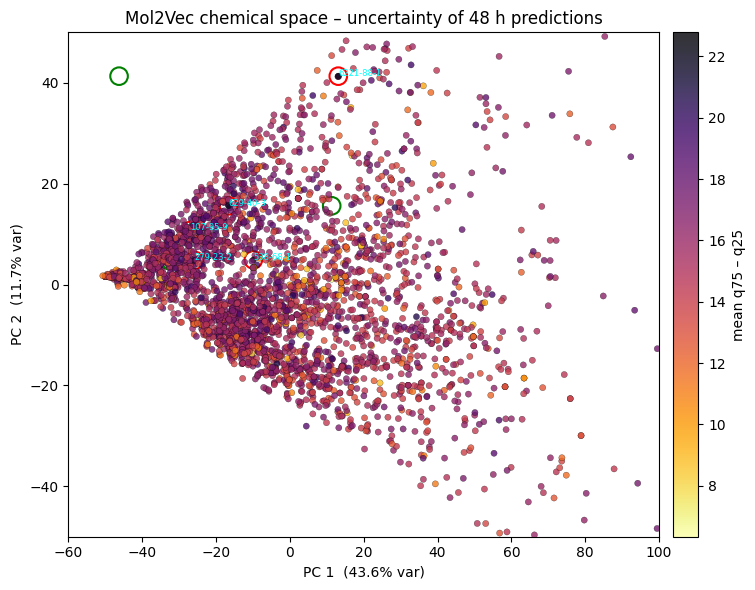

In [ ]:
# ------------------------------------------------------------
# 0  — paths and column list
# ------------------------------------------------------------
PRED_CSV       = "quantile_predictions_48h_stream.csv"        # from previous step
ECO_MORTALITY  = "data_files/ecotox_mortality_processed.csv"
ECO_PROPS      = "data_files/ecotox_properties_with-oecd-function.csv"

mol_cols = [f"chem_mol2vec{str(i).zfill(3)}" for i in range(300)]

# ------------------------------------------------------------
# 1  — load Mol2Vec per CAS (one row each)
# ------------------------------------------------------------
import pandas as pd, numpy as np

data, _ = load_ecotox_data(
    adore_path      = ECO_MORTALITY,
    chemicals_path  = ECO_PROPS,
    use_mol2vec     = True,
    mol2vec_path    = None,
    mol2vec_cols    = mol_cols,
)

mol2vec_per_cas = (data
                   .drop_duplicates("CAS")        # one record per chemical
                   .set_index("CAS")[mol_cols]    # keep only Mol2Vec
                   .sort_index())

print("Mol2Vec matrix →", mol2vec_per_cas.shape)   # (n_CAS × 300)

# ------------------------------------------------------------
# 2  — per-chemical uncertainty statistics
# ------------------------------------------------------------
pred = pd.read_csv(PRED_CSV)

chem_stats = (pred[pred["well_defined"]]
              .groupby("CAS")["uncertainty"]
              .agg(avg_unc = "mean", n = "size"))

# keep only chemicals that have Mol2Vec (slightly less than full CSV if any CAS missing)
common = mol2vec_per_cas.index.intersection(chem_stats.index)
mol2vec   = mol2vec_per_cas.loc[common].to_numpy(dtype=np.float32)
chem_stats = chem_stats.loc[common]

print(f"Analysing {len(common)} chemicals with Mol2Vec + uncertainty")

# ------------------------------------------------------------
# 3  — PCA → 2-D
# ------------------------------------------------------------
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=0, whiten=False)
xy  = pca.fit_transform(mol2vec)

coords = pd.DataFrame(xy, columns=["PC1", "PC2"], index=common)
coords = coords.join(chem_stats)        # add avg_unc and n

# ------------------------------------------------------------
# 4  — plot
# ------------------------------------------------------------
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(coords["PC1"], coords["PC2"],
                c=coords["avg_unc"],
                cmap=plt.cm.inferno_r,
                s=20,                # <- all dots small
                alpha=0.8, linewidths=0.2, edgecolors="k", zorder = 3)

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("mean q75 – q25")

ax.set_xlabel(f"PC 1  ({pca.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC 2  ({pca.explained_variance_ratio_[1]:.1%} var)")
ax.set_title("Mol2Vec chemical space – uncertainty of 48 h predictions")
ax.set_xlim(-60, 100)   
ax.set_ylim(-50,  50)  
# highlight worst 5 chemicals (optional)
worst = coords.nlargest(5, "avg_unc")
ax.scatter(worst["PC1"], worst["PC2"],
           facecolors="none", edgecolors="red", s=160, lw=1.5)
best = coords.nsmallest(5, "avg_unc")
ax.scatter(best["PC1"], worst["PC2"],
           facecolors="none", edgecolors="green", s=160, lw=1.5)


for cas, row in worst.iterrows():
    ax.text(row["PC1"], row["PC2"], cas, color="cyan", fontsize=6)

plt.tight_layout()
plt.show()
